In [1]:
import numpy as np
import sys
#sys.path.append('/path/to/denoised_structural_connectivity')
from denoise_structural_connectivity import denoise_matrix
from bipca import plotting
import seaborn as sns

In [2]:
X = np.load('/Users/KARATB01/streamline_count_matrix.npy')
X.shape

(100, 100, 506)

### Can see we have a connectivity matrix of size 100 x 100 across 506 subjects

### Let's plot example streamline count matrix from one subject

<Axes: >

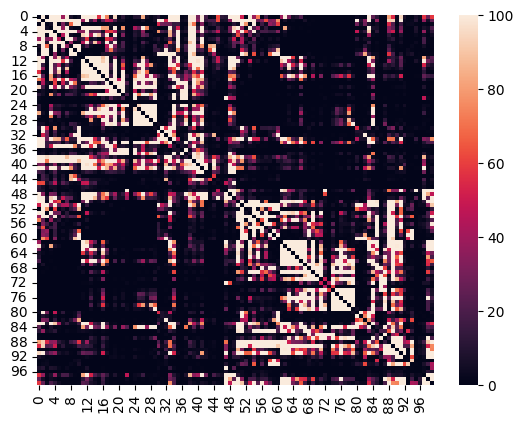

In [30]:
sns.heatmap(X[:,:,0],vmin=0,vmax=100)

In [2]:
help(denoise_matrix)

Help on function denoise_matrix in module denoise_structural_connectivity:

denoise_matrix(X, threshold=10, unscale=True)
    X: array (M, M, N)
        Input streamline count matrix, where M is number of regions and N is number of subjects
    Threshold: int
        Global nonzero threshold for the rows and columns of the matrix (default=10)
    unscale: bool
        Unscale the denoised matrix to map back to the original scale (default=True)

    Returns:
    X_d: array (M, M, N)
        Denoised streamline count matrix, where M is number of regions and N is number of subjects
    KS_mean: scalar
        Mean Kolmogorov-Smirnov statistic for how closely the denoised spectrum follows the MP distribution.
    spectrum: list
        Returns the plotting spectrum of variable size depending on the number of submatrices empirically chosen for denoising



### Perform denoising

In [6]:
X_d, KS_mean, spectrum = denoise_matrix(X,threshold=2)

Calculating BiPCA fit...
  Calculating variance fit over entire input...
    Chebyshev approximation of KS reached 2.5678301014128847e-08 with 65 coefficients
    Estimated b=0.29843686164560257, c=0.6160784251640169, KS=0.10253646101335212
    Approximating the mean of all submatrices
    Approximation ratio is 2.5678301014112208e-08 with 65 coefficients
    b=0.2984461979163873, c=0.61609769850367
  Calculated variance fit over entire input in 1.44 seconds.
  Calculating Sinkhorn biscaling with dense torch backend...
    Sinkhorn converged early after 40 iterations.
  Calculating dense Biscaling transform...
  Calculating rank k=506 dense exact singular value decomposition using __compute_torch_svd....
  Calculated rank k=506 dense exact singular value decomposition using __compute_torch_svd. in 0.03 seconds.
  Calculating Shrinker fit...
    Calculating MP Parameter estimate...
      Estimated noise variance computed from the 50th percentile is 1.000
      Scaled Marcenko-Pastur ran

### Plot the spectrum from the empirically determined sub-matrix bin-size

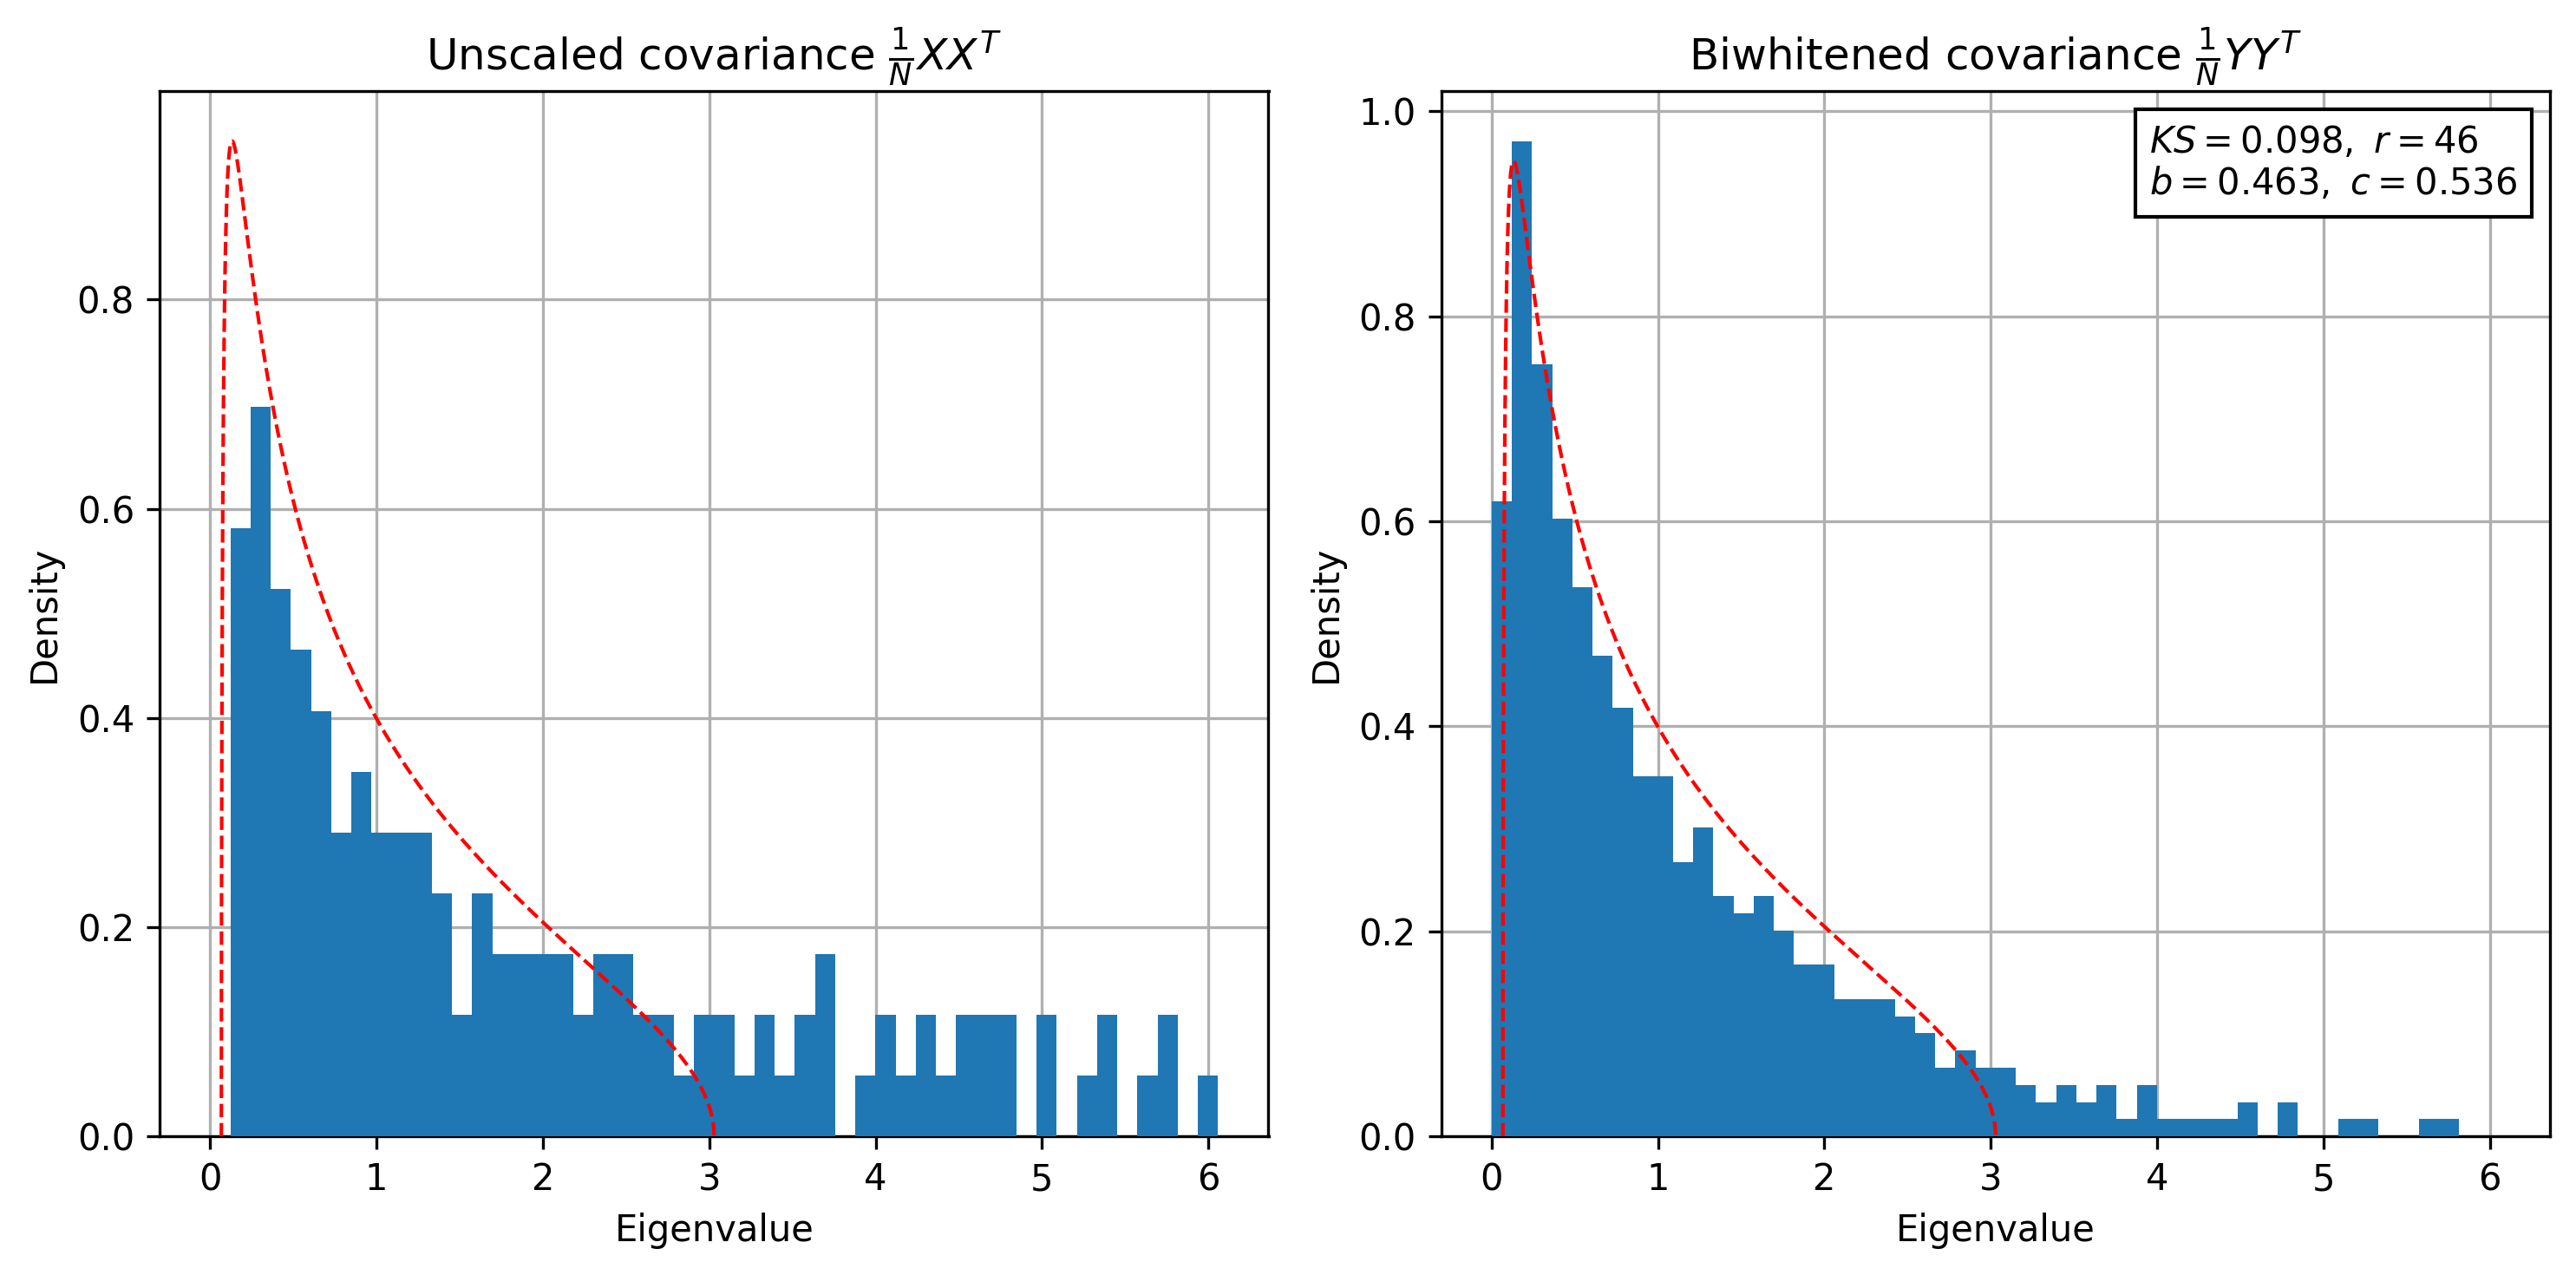

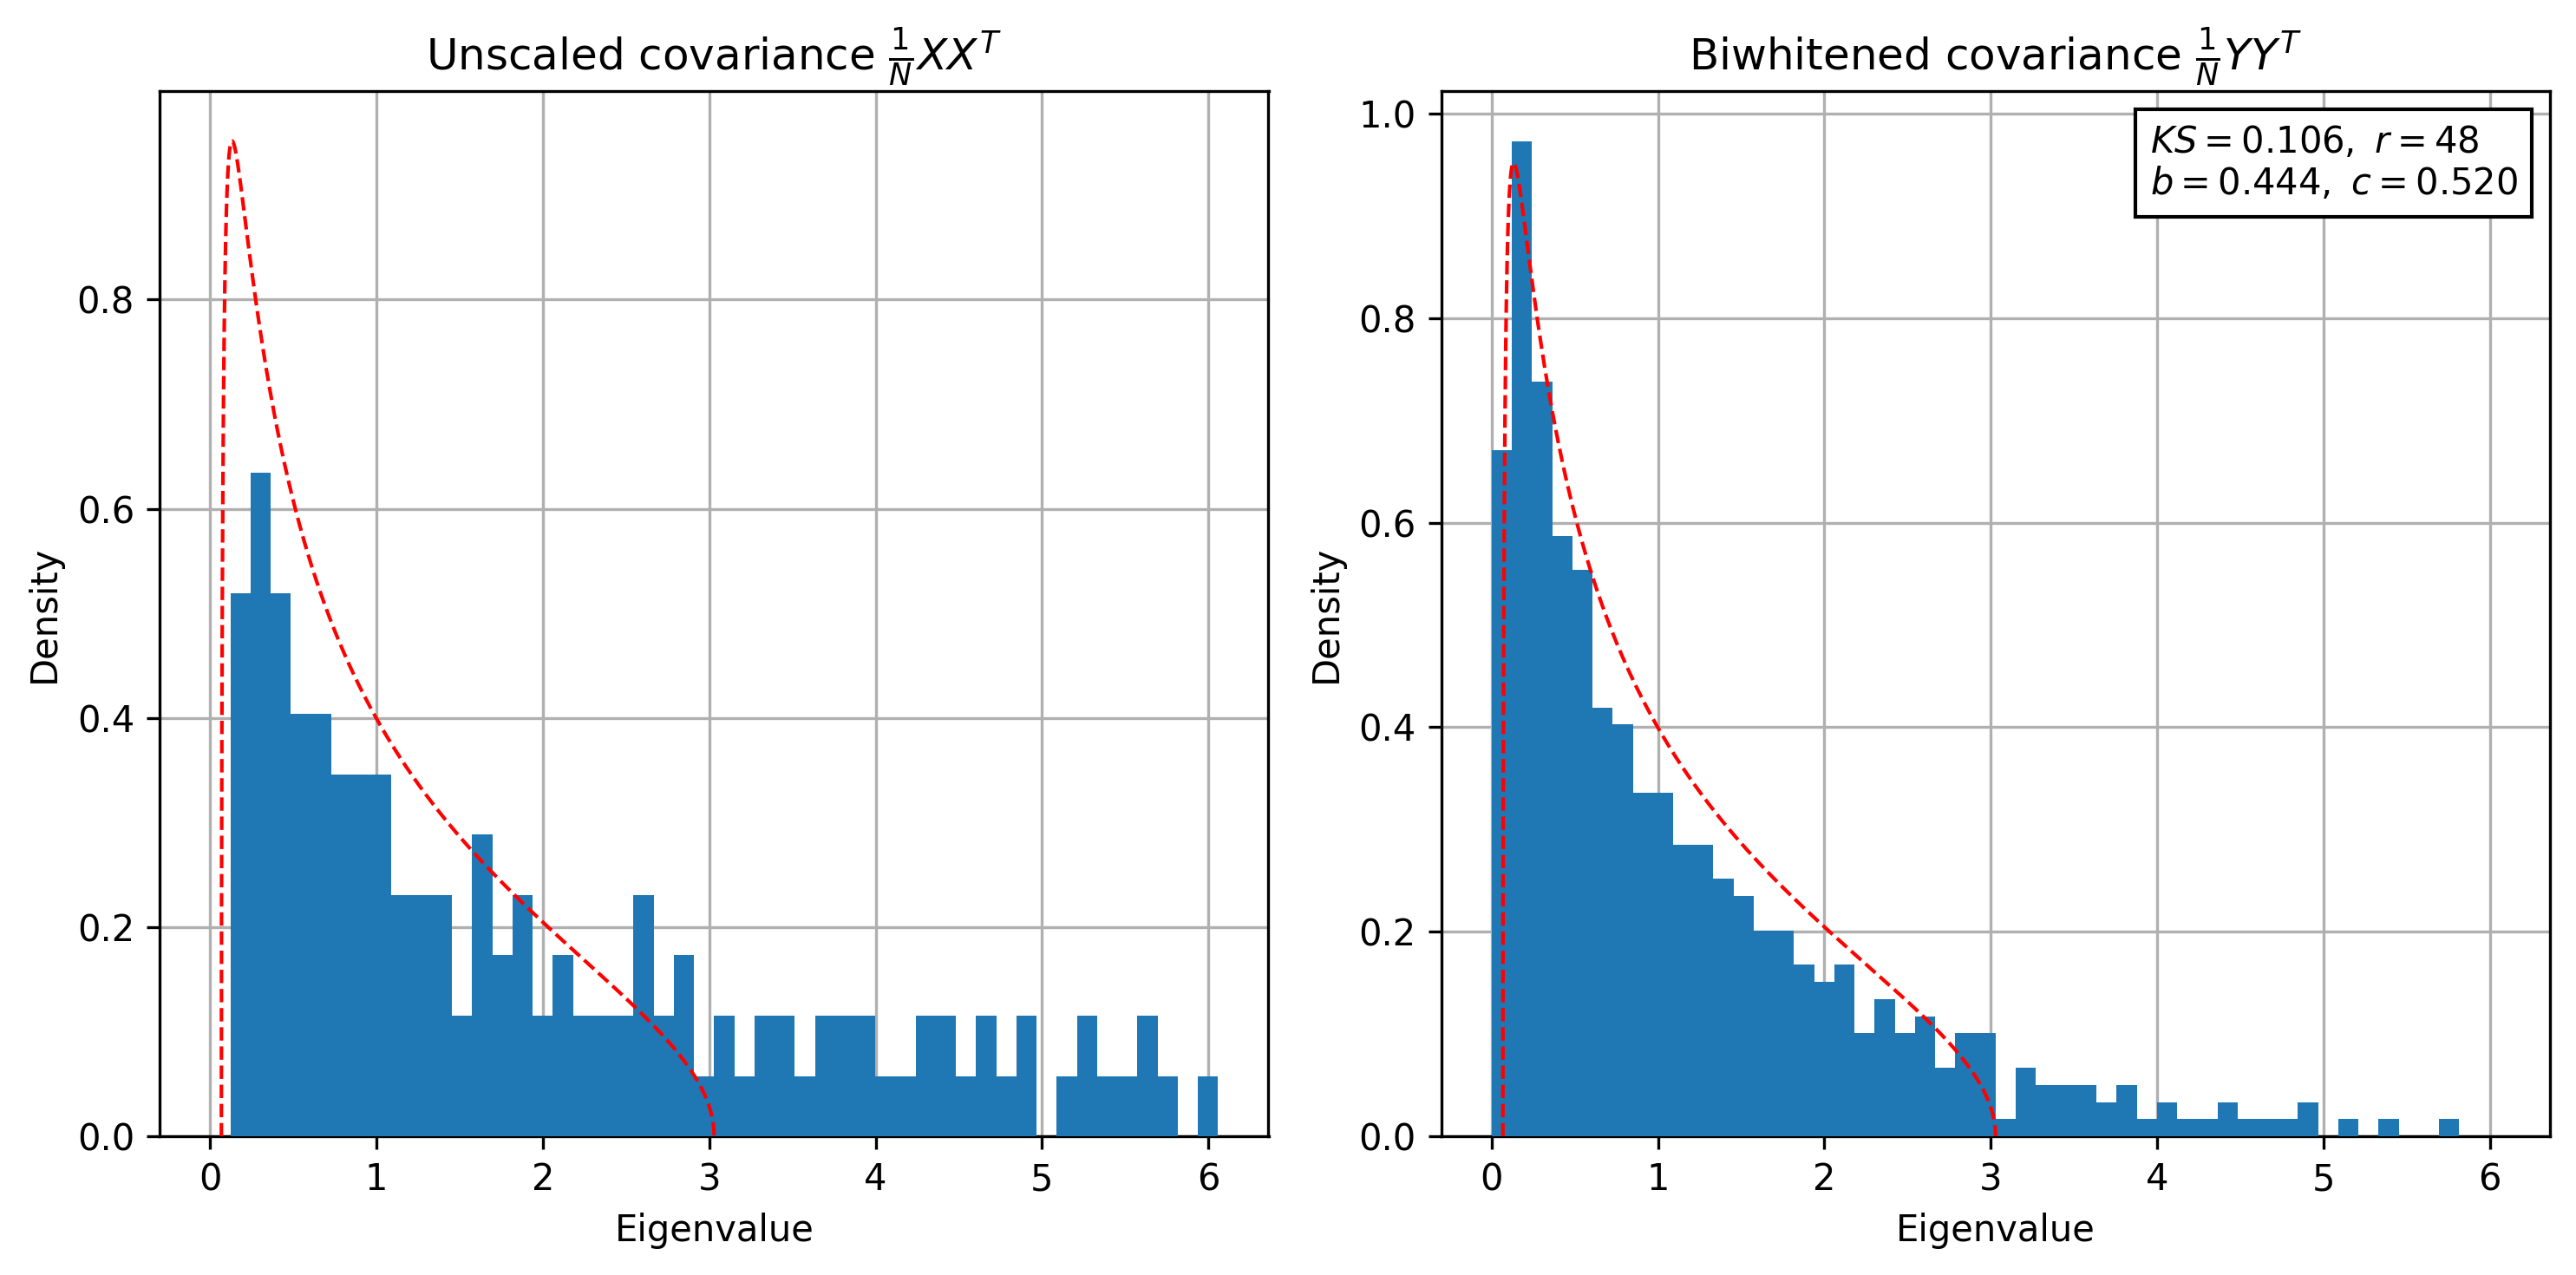

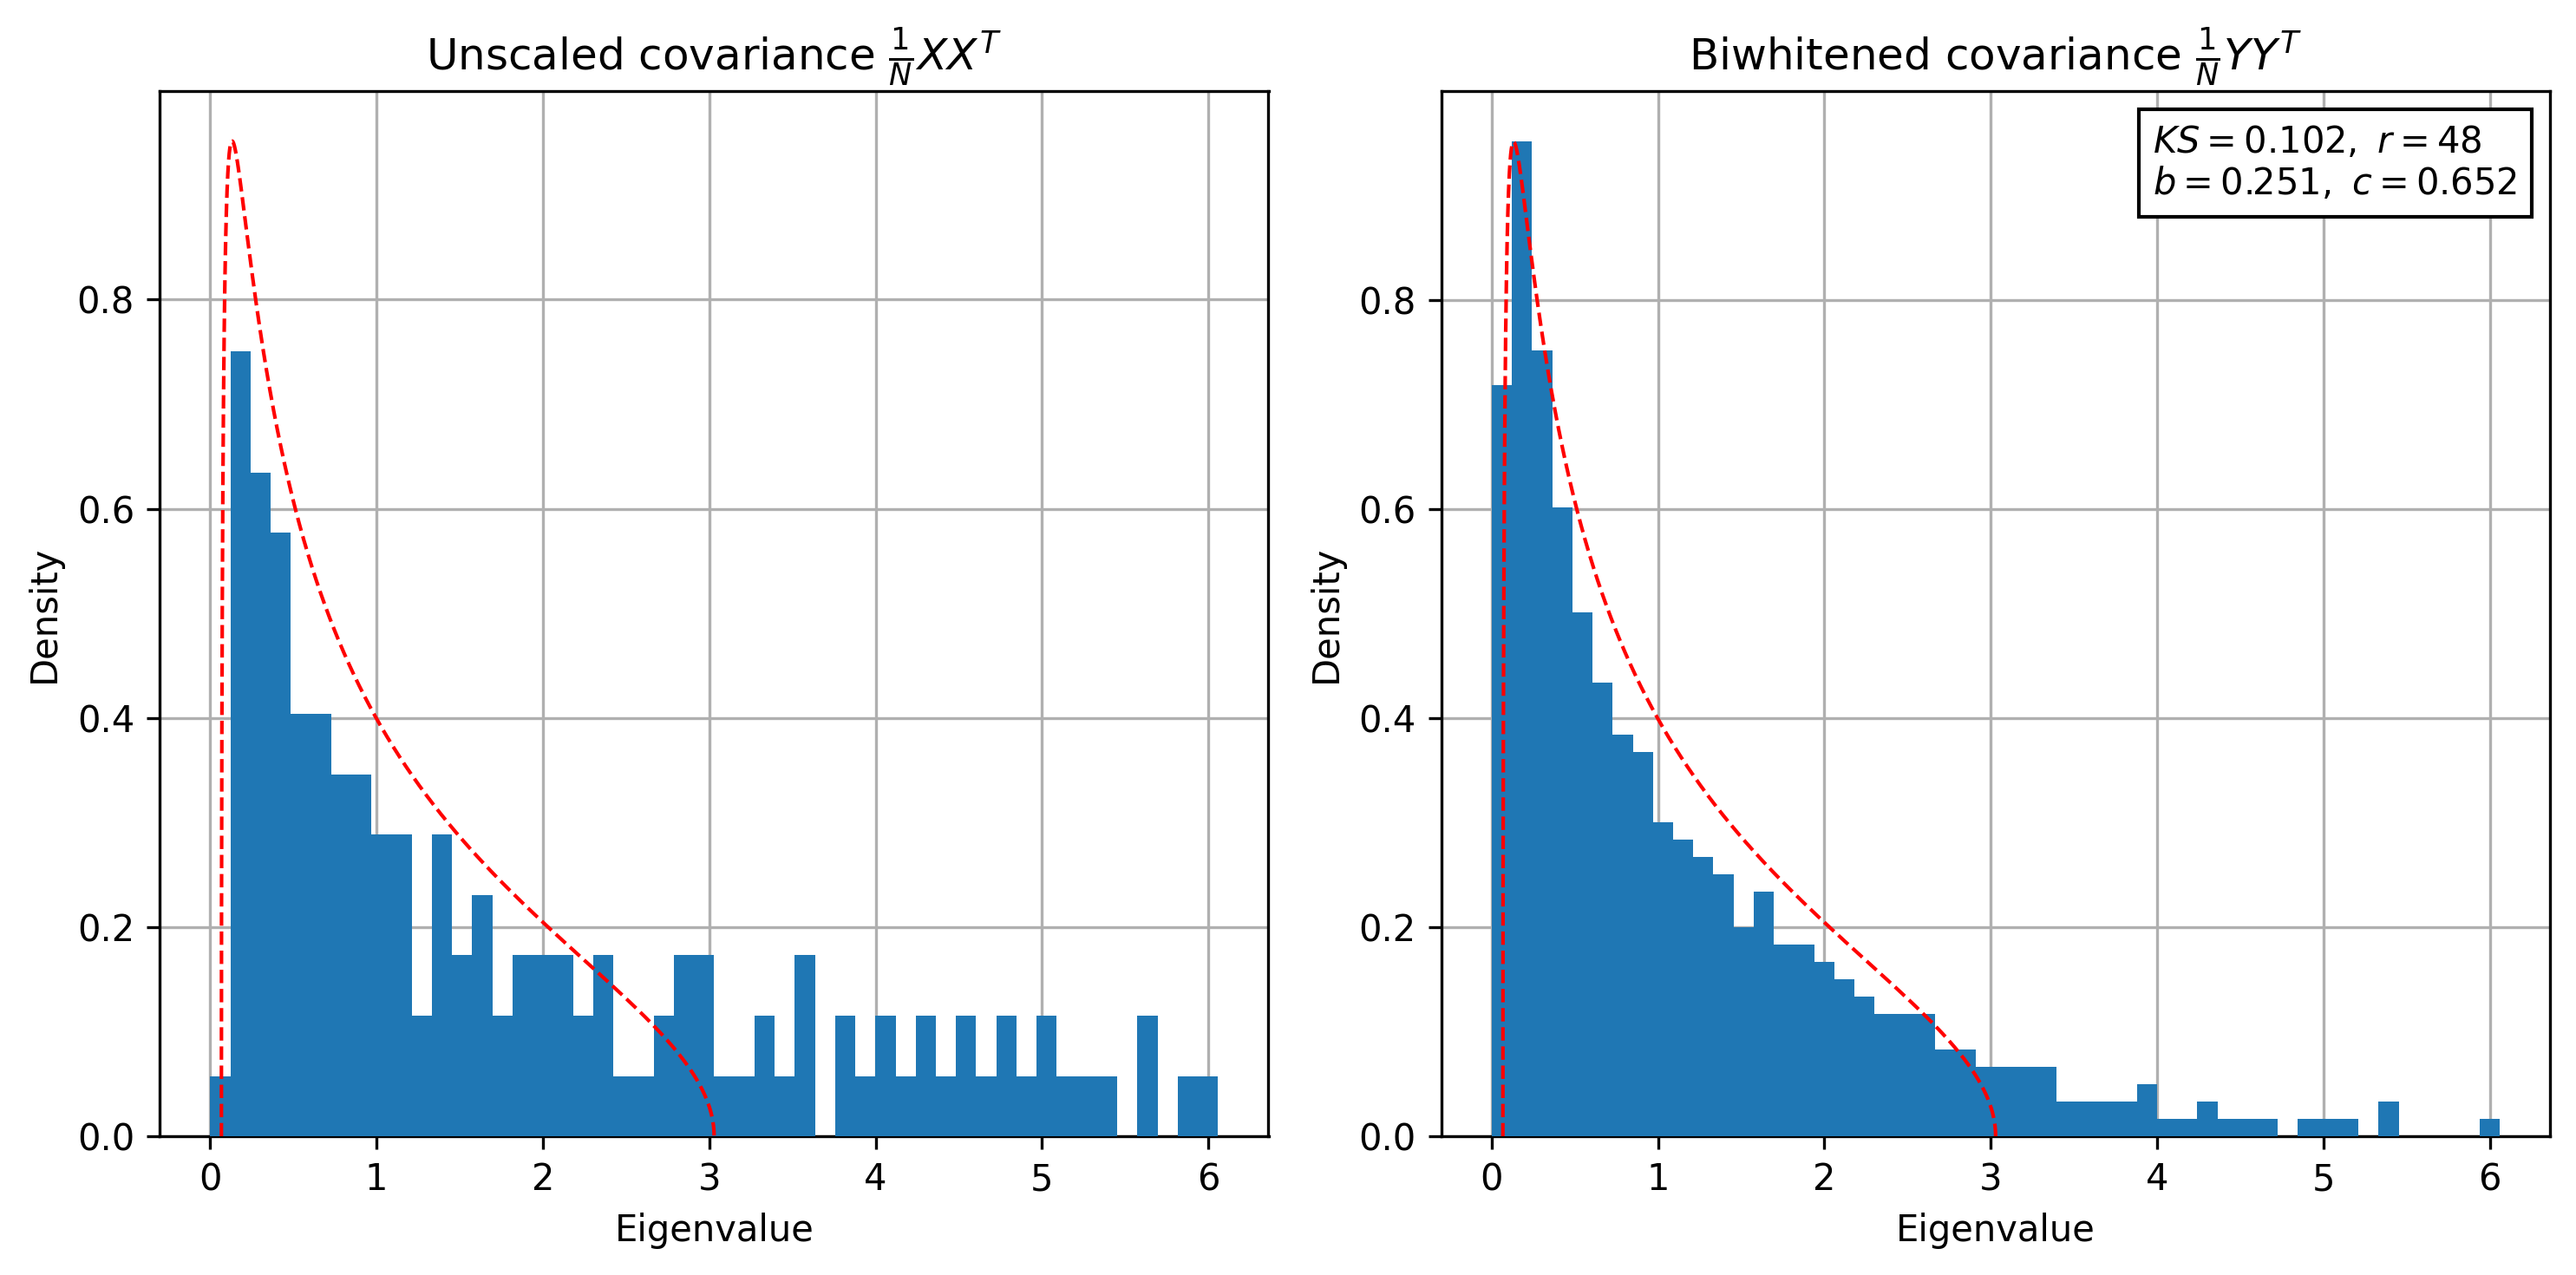

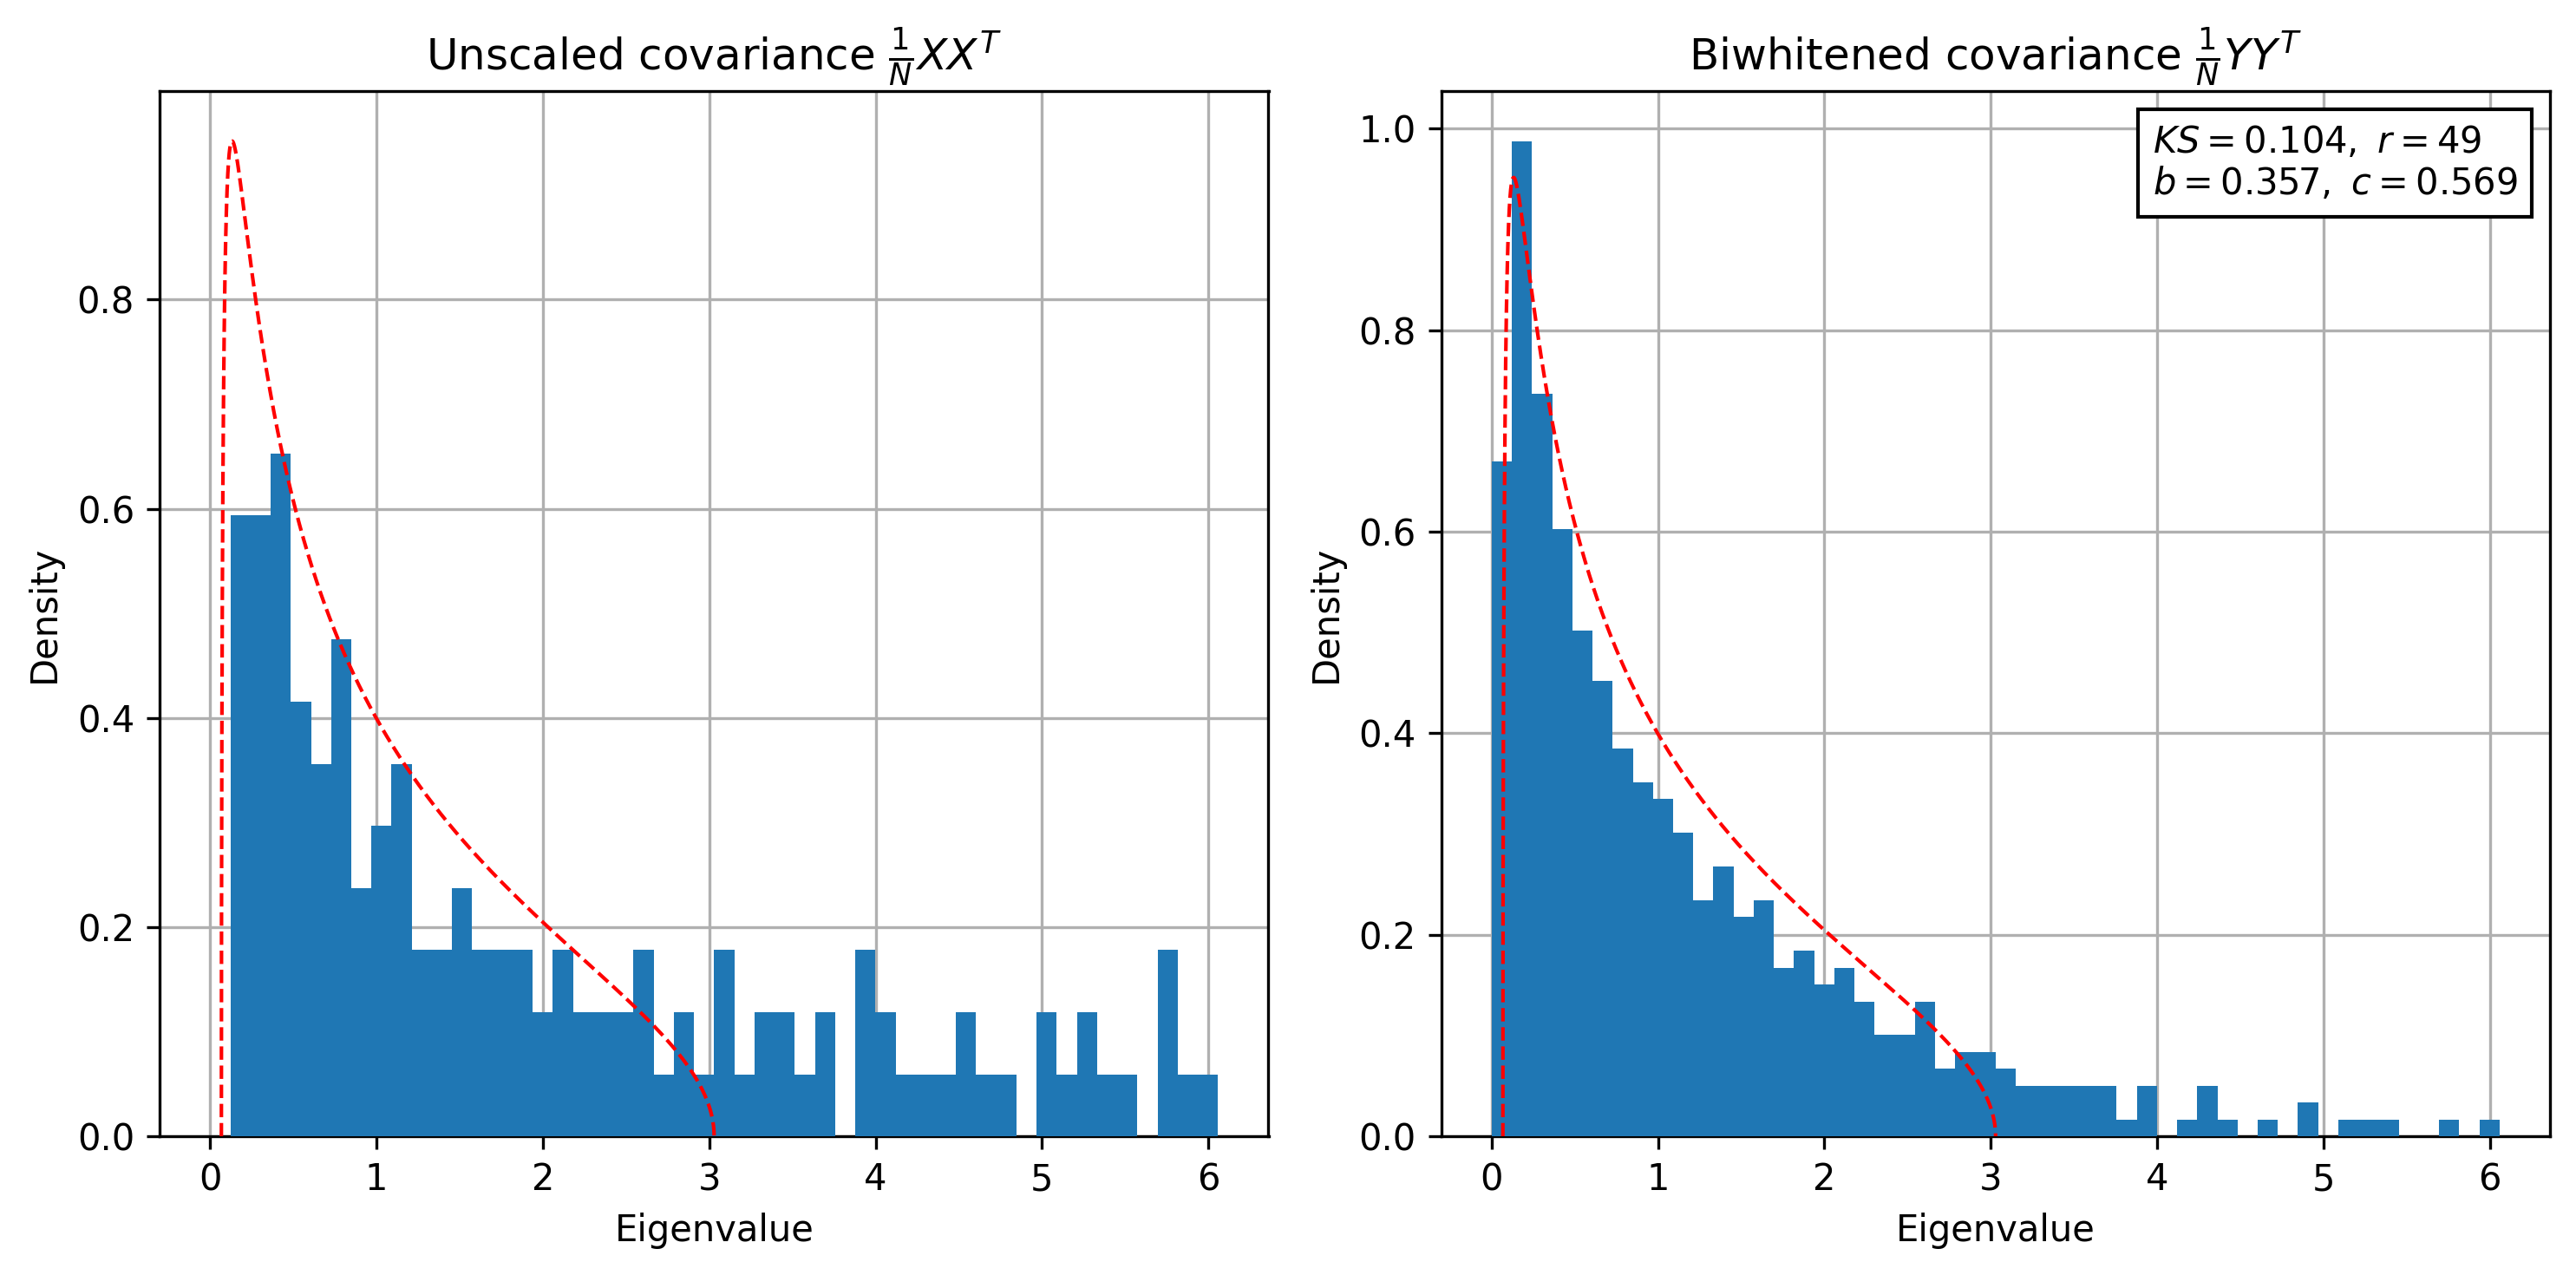

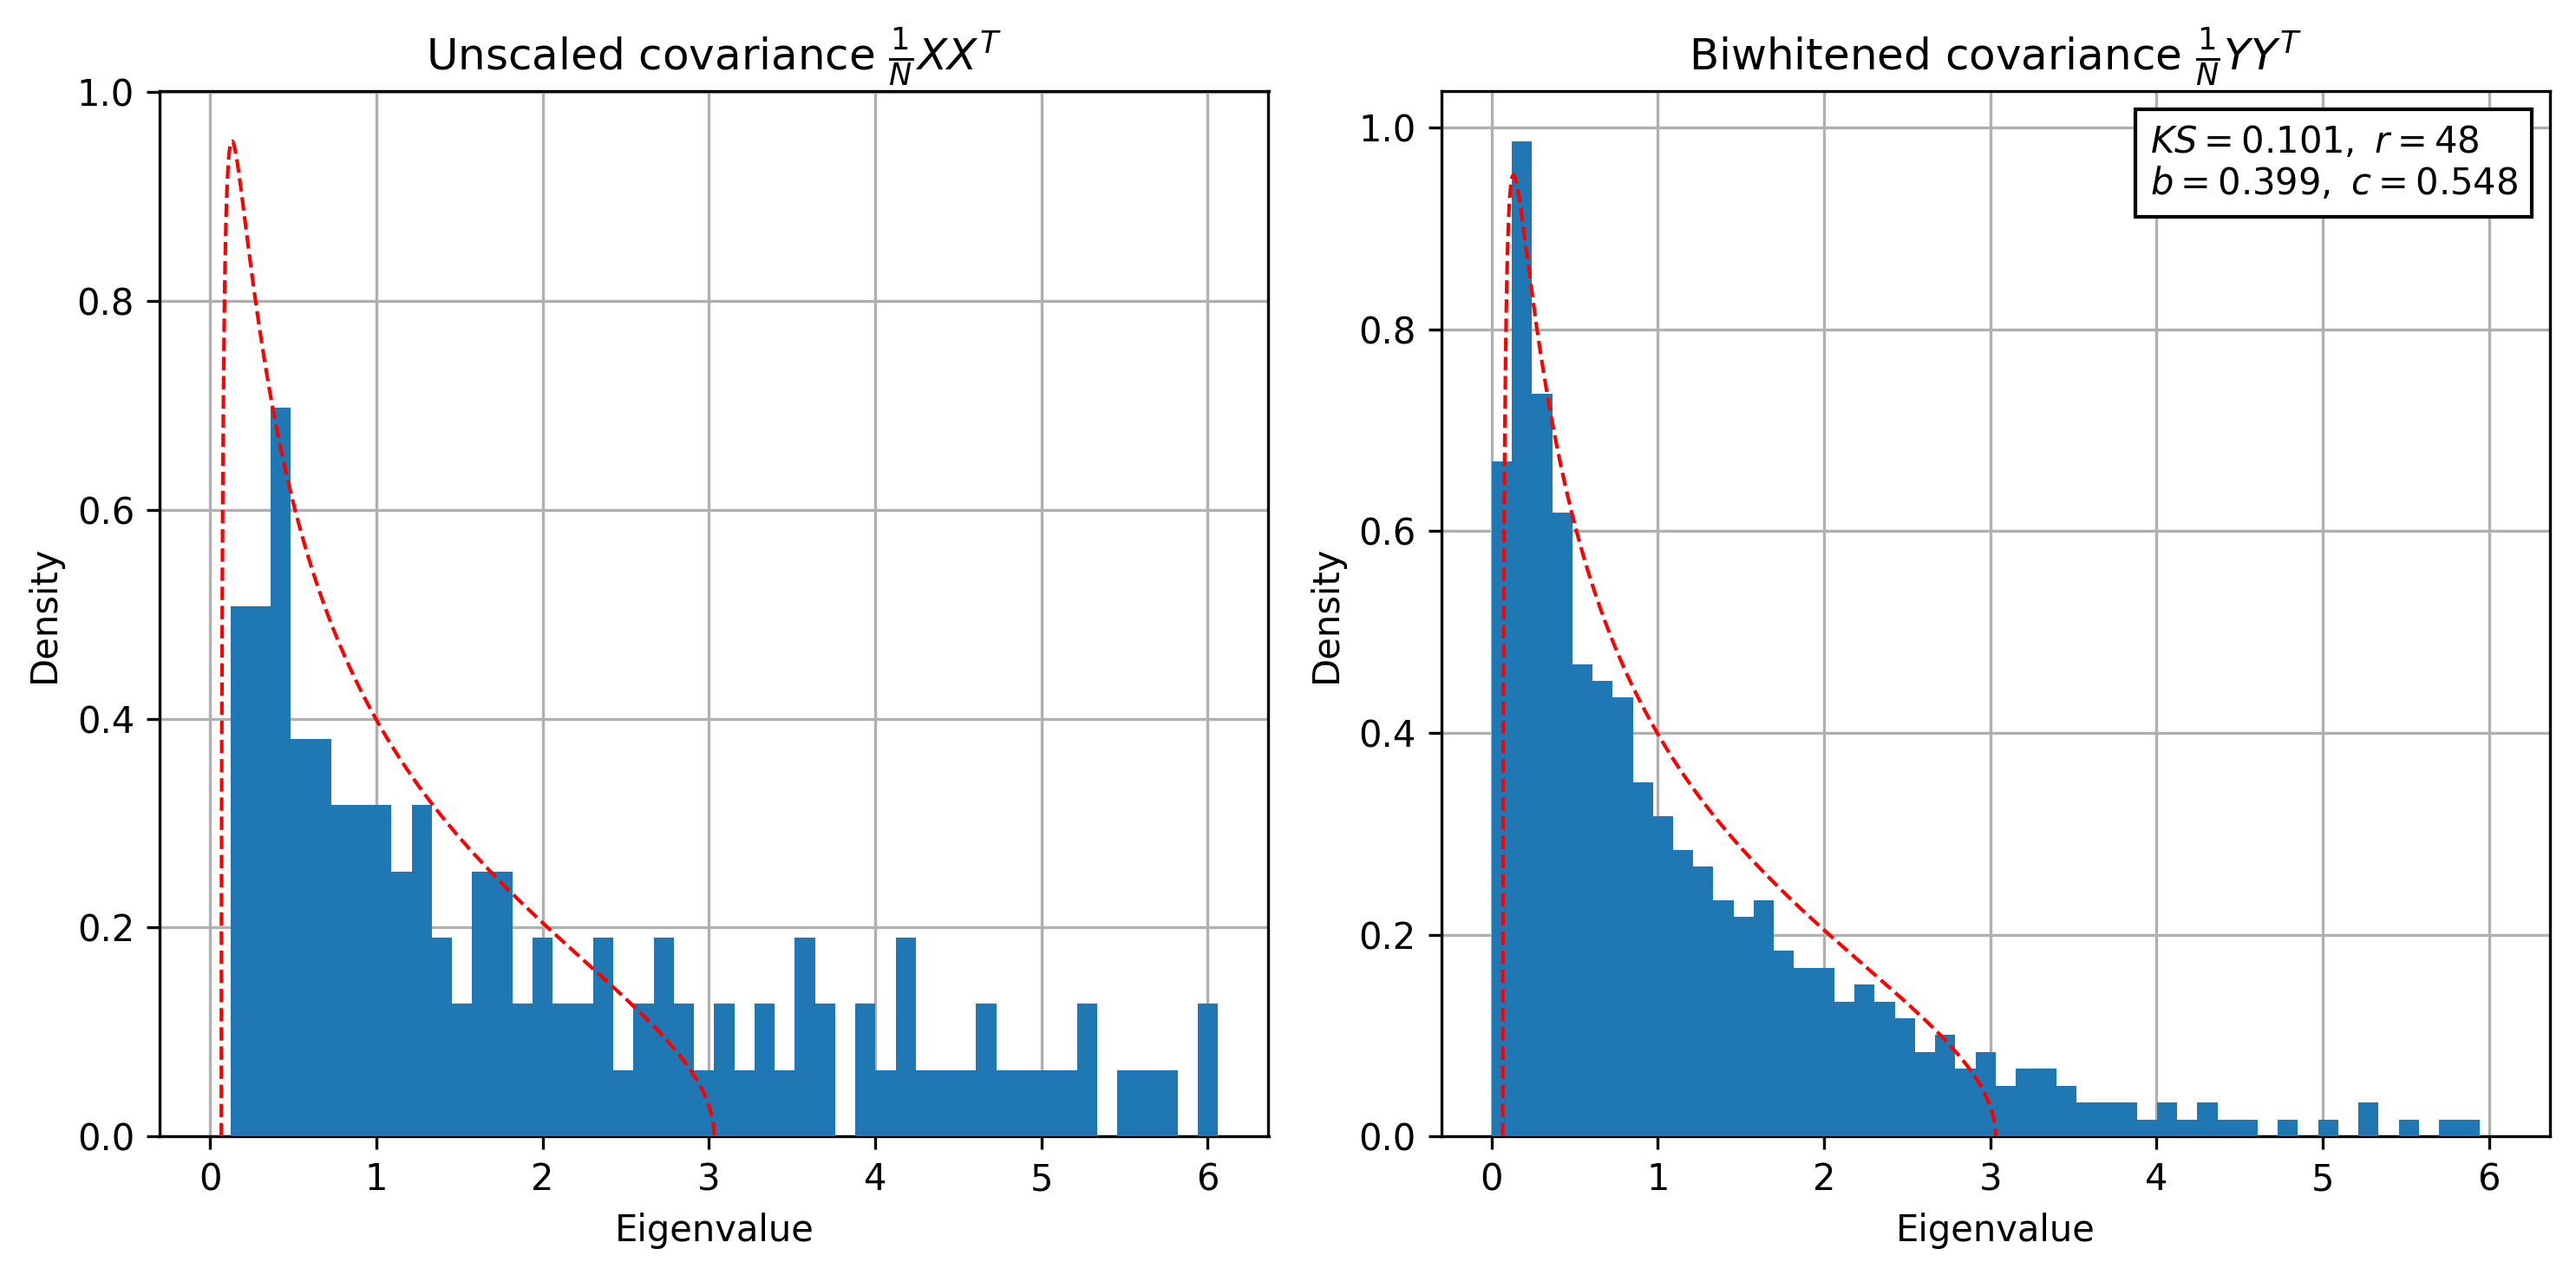

In [36]:
for spect in spectrum:
    plotting.MP_histograms_from_bipca(spect,both=True,median= False,bins=50)

In [7]:
X_d.shape

(100, 100, 506)

### Plot denoised count matrix from same subject above

<Axes: >

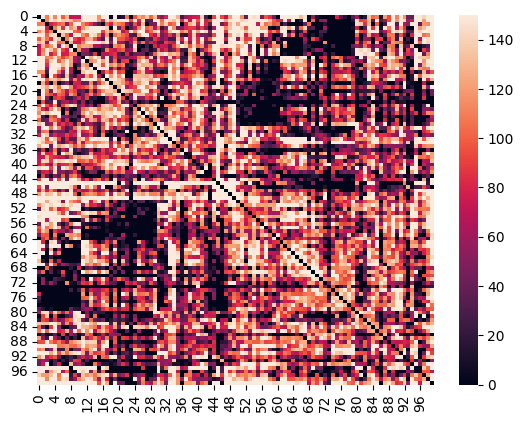

In [28]:
sns.heatmap(X_d[:,:,0],vmin=0,vmax=150)